# Análisis y predicción de la recaudación tributaria del Ecuador mediante técnicas de minería de datos

### Asignatura: Minería de Datos
### Unidad: Unidad 4 – Aplicaciones de Data Mining
### Dataset: Recaudación tributaria del SRI – 2026
### Período de análisis: Enero – Julio de 2026

In [2]:
# ============================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================

# Pandas:
# Se utilizará para cargar, organizar, analizar y transformar
# el conjunto de datos del SRI.
import pandas as pd


# NumPy:
# Se utilizará para realizar operaciones matemáticas y numéricas,
# además de realizar algunas transformaciones sobre los datos.
import numpy as np


# Matplotlib:
# Se utilizará para crear gráficos y visualizar los resultados
# obtenidos durante el análisis exploratorio y el modelado.
import matplotlib.pyplot as plt


# Seaborn:
# Se utilizará para generar visualizaciones estadísticas,
# como histogramas, gráficos de barras, boxplots y mapas de calor.
import seaborn as sns


# ============================================
# 2. PREPARACIÓN Y DIVISIÓN DE LOS DATOS
# ============================================

# train_test_split:
# Permite dividir el conjunto de datos en datos de entrenamiento
# y datos de prueba para evaluar el rendimiento de los modelos.
from sklearn.model_selection import train_test_split


# KFold:
# Se utilizará para realizar validación cruzada mediante
# diferentes particiones del conjunto de datos.
#
# cross_val_score:
# Permitirá calcular el rendimiento de los modelos mediante
# validación cruzada.
from sklearn.model_selection import KFold, cross_val_score


# ============================================
# 3. PREPROCESAMIENTO DE LOS DATOS
# ============================================

# OneHotEncoder:
# Se utilizará para convertir variables categóricas,
# como provincia, cantón o tipo de contribuyente,
# en variables numéricas que puedan ser utilizadas
# por los modelos de aprendizaje automático.
from sklearn.preprocessing import OneHotEncoder


# ColumnTransformer:
# Permitirá aplicar diferentes transformaciones a diferentes
# grupos de variables del conjunto de datos.
#
# Por ejemplo:
# - Variables numéricas: tratamiento numérico.
# - Variables categóricas: codificación One-Hot.
from sklearn.compose import ColumnTransformer


# Pipeline:
# Permitirá organizar en una secuencia las etapas de
# preprocesamiento y modelado.
#
# De esta manera se mantiene un flujo ordenado:
# datos → transformación → modelo → predicción.
from sklearn.pipeline import Pipeline


# ============================================
# 4. MODELO DE REGRESIÓN LINEAL
# ============================================

# LinearRegression:
# Implementa un modelo de regresión lineal que utilizaremos
# para realizar predicciones sobre el valor de la recaudación.
#
# Este modelo servirá también como referencia para comparar
# posteriormente su rendimiento con otros modelos.
from sklearn.linear_model import LinearRegression


# ============================================
# 5. MODELOS BASADOS EN ÁRBOLES
# ============================================

# RandomForestRegressor:
# Implementa un modelo de Random Forest para regresión.
#
# Utiliza múltiples árboles de decisión y permite identificar
# relaciones no lineales entre las variables y el valor
# de recaudación.
from sklearn.ensemble import RandomForestRegressor


# HistGradientBoostingRegressor:
# Implementa un modelo basado en Gradient Boosting.
#
# Será utilizado como una tercera técnica de minería de datos
# para comparar su capacidad predictiva con la regresión lineal
# y Random Forest.
from sklearn.ensemble import HistGradientBoostingRegressor


# ============================================
# 6. MÉTRICAS DE EVALUACIÓN
# ============================================

# mean_absolute_error:
# Calcula el Error Absoluto Medio (MAE).
#
# Permite conocer cuánto se alejan, en promedio,
# las predicciones de los valores reales.
from sklearn.metrics import mean_absolute_error


# mean_squared_error:
# Calcula el Error Cuadrático Medio (MSE).
#
# Se utilizará para medir el error de las predicciones,
# dando mayor importancia a los errores grandes.
from sklearn.metrics import mean_squared_error


# r2_score:
# Calcula el coeficiente de determinación R².
#
# Permite evaluar qué tan bien el modelo explica
# la variabilidad de los valores reales.
from sklearn.metrics import r2_score


# ============================================
# 7. CONFIGURACIÓN DE ADVERTENCIAS
# ============================================

# warnings:
# Librería utilizada para controlar los mensajes de
# advertencia que pueden aparecer durante la ejecución.
import warnings


# filterwarnings("ignore"):
# Permite ocultar determinadas advertencias para mantener
# más limpia la presentación de resultados en Google Colab.
#
# Nota: esto no elimina errores; solamente oculta advertencias.
warnings.filterwarnings("ignore")


# ============================================
# 8. COMPROBACIÓN DE LAS LIBRERÍAS
# ============================================

# Mensaje para comprobar que la importación de las
# librerías se realizó correctamente.
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga del conjunto de datos desde Google Drive

Para facilitar el acceso y la reutilización del conjunto de datos,
el archivo `sri_recaudacion_2026.csv` se almacenará en Google Drive.

Google Colab se conectará con Google Drive mediante la librería
`google.colab.drive`, permitiendo acceder al archivo directamente
desde el entorno de trabajo.

In [3]:
# ============================================
# 2.1. CONEXIÓN CON GOOGLE DRIVE
# ============================================

# Importamos la herramienta que permite conectar
# Google Colab con nuestra cuenta de Google Drive.
from google.colab import drive

# Montamos Google Drive en el entorno de Colab.
# Al ejecutar esta instrucción, Colab solicitará
# autorización para acceder a nuestro Drive.
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ============================================
# 2.3. CARGA DEL DATASET
# ============================================

# Ruta del archivo almacenado en Google Drive.
ruta_archivo = '/content/drive/MyDrive/sri_recaudacion_2026.csv'

# Leemos el archivo CSV utilizando Pandas.
#
# sep='|' indica que las columnas están separadas
# por el carácter vertical |.
#
# encoding='latin1' permite interpretar correctamente
# caracteres especiales presentes en el archivo.
df = pd.read_csv(
    ruta_archivo,
    sep='|',
    encoding='latin1'
)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [6]:
# ============================================
# 2.4. COMPROBACIÓN DEL DATASET
# ============================================

# Mostramos la cantidad de registros y variables.
filas, columnas = df.shape

print("Número de registros:", filas)
print("Número de variables:", columnas)

# Mostramos los primeros cinco registros.
df.head()

Número de registros: 420031
Número de variables: 11


,ANIO,MES,GRUPO_IMPUESTO,SUBGRUPO_IMPUESTO,IMPUESTO,GRAN_CONTRIBUYENTE,CODIGO_OPERA_FAMILIA,TIPO_CONTRIBUYENTE,PROVINCIA,CANTON,VALOR_RECAUDADO
0,2026,01 Enero,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,G,PERSONAS NATURALES,LOS RIOS,PALENQUE,"79,6400"
1,2026,01 Enero,IMPUESTO AL VALOR AGREGADO,IVA OPERACIONES INTERNAS,IVA MENSUAL,NO,G,SOCIEDADES,PICHINCHA,QUITO,"181622053,6700"
2,2026,01 Enero,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,S,PERSONAS NATURALES,IMBABURA,IBARRA,"3575,2600"
3,2026,01 Enero,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,S,PERSONAS NATURALES,GUAYAS,GUAYAQUIL,"39697,3000"
4,2026,01 Enero,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,S,PERSONAS NATURALES,PICHINCHA,MEJIA,"879,8200"


## 3. Exploración inicial del conjunto de datos

En esta etapa se realizará una exploración inicial del conjunto de datos
con el propósito de conocer su estructura, las variables disponibles,
los tipos de datos y la cantidad de registros no nulos.

Esta revisión permitirá identificar las características generales del
dataset antes de realizar las etapas de limpieza, transformación y
modelado.

In [7]:
# ============================================
# 3.1. INFORMACIÓN GENERAL DEL DATASET
# ============================================

# info() muestra información general del DataFrame:
# - cantidad de registros
# - nombre de las variables
# - cantidad de valores no nulos
# - tipo de dato de cada variable
# - memoria utilizada
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420031 entries, 0 to 420030
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   ANIO                  420031 non-null  int64 
 1   MES                   420031 non-null  object
 2   GRUPO_IMPUESTO        420031 non-null  object
 3   SUBGRUPO_IMPUESTO     420031 non-null  object
 4   IMPUESTO              420031 non-null  object
 5   GRAN_CONTRIBUYENTE    420031 non-null  object
 6   CODIGO_OPERA_FAMILIA  420031 non-null  object
 7   TIPO_CONTRIBUYENTE    420031 non-null  object
 8   PROVINCIA             420031 non-null  object
 9   CANTON                420031 non-null  object
 10  VALOR_RECAUDADO       420031 non-null  object
dtypes: int64(1), object(10)
memory usage: 35.3+ MB


In [8]:
# ============================================
# 3.2. NOMBRES DE LAS VARIABLES
# ============================================

# Mostramos el nombre de cada columna del dataset.
print("Variables disponibles:\n")

for numero, columna in enumerate(df.columns, start=1):
    print(f"{numero}. {columna}")

Variables disponibles:

1. ANIO
2. MES
3. GRUPO_IMPUESTO
4. SUBGRUPO_IMPUESTO
5. IMPUESTO
6. GRAN_CONTRIBUYENTE
7. CODIGO_OPERA_FAMILIA
8. TIPO_CONTRIBUYENTE
9. PROVINCIA
10. CANTON
11. VALOR_RECAUDADO


In [9]:
# ============================================
# 3.3. TIPOS DE DATOS
# ============================================

# Mostramos el tipo de dato que Pandas asignó
# a cada variable.
df.dtypes

,0
ANIO,int64
MES,object
GRUPO_IMPUESTO,object
SUBGRUPO_IMPUESTO,object
IMPUESTO,object
GRAN_CONTRIBUYENTE,object
CODIGO_OPERA_FAMILIA,object
TIPO_CONTRIBUYENTE,object
PROVINCIA,object
CANTON,object


In [10]:
# ============================================
# 3.4. PRIMEROS REGISTROS
# ============================================

# Mostramos los primeros cinco registros para
# observar la estructura y contenido de los datos.
df.head()

,ANIO,MES,GRUPO_IMPUESTO,SUBGRUPO_IMPUESTO,IMPUESTO,GRAN_CONTRIBUYENTE,CODIGO_OPERA_FAMILIA,TIPO_CONTRIBUYENTE,PROVINCIA,CANTON,VALOR_RECAUDADO
0,2026,01 Enero,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,G,PERSONAS NATURALES,LOS RIOS,PALENQUE,"79,6400"
1,2026,01 Enero,IMPUESTO AL VALOR AGREGADO,IVA OPERACIONES INTERNAS,IVA MENSUAL,NO,G,SOCIEDADES,PICHINCHA,QUITO,"181622053,6700"
2,2026,01 Enero,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,S,PERSONAS NATURALES,IMBABURA,IBARRA,"3575,2600"
3,2026,01 Enero,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,S,PERSONAS NATURALES,GUAYAS,GUAYAQUIL,"39697,3000"
4,2026,01 Enero,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,S,PERSONAS NATURALES,PICHINCHA,MEJIA,"879,8200"


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420031 entries, 0 to 420030
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   ANIO                  420031 non-null  int64 
 1   MES                   420031 non-null  object
 2   GRUPO_IMPUESTO        420031 non-null  object
 3   SUBGRUPO_IMPUESTO     420031 non-null  object
 4   IMPUESTO              420031 non-null  object
 5   GRAN_CONTRIBUYENTE    420031 non-null  object
 6   CODIGO_OPERA_FAMILIA  420031 non-null  object
 7   TIPO_CONTRIBUYENTE    420031 non-null  object
 8   PROVINCIA             420031 non-null  object
 9   CANTON                420031 non-null  object
 10  VALOR_RECAUDADO       420031 non-null  object
dtypes: int64(1), object(10)
memory usage: 35.3+ MB


In [12]:
df.dtypes

,0
ANIO,int64
MES,object
GRUPO_IMPUESTO,object
SUBGRUPO_IMPUESTO,object
IMPUESTO,object
GRAN_CONTRIBUYENTE,object
CODIGO_OPERA_FAMILIA,object
TIPO_CONTRIBUYENTE,object
PROVINCIA,object
CANTON,object


## 4. Análisis de calidad de los datos

Antes de realizar el preprocesamiento, se evaluará la calidad del conjunto
de datos mediante la identificación de valores nulos.

Los valores nulos representan información ausente dentro de una variable.
Su identificación es importante porque puede afectar posteriormente los
procesos de análisis y construcción de los modelos de minería de datos.

Se calculará tanto la cantidad de valores nulos como su porcentaje
respecto al total de registros.

In [13]:
# ============================================
# 4.1. ANÁLISIS DE VALORES NULOS
# ============================================

# Calculamos la cantidad de valores nulos
# existentes en cada variable.
valores_nulos = df.isnull().sum()

# Calculamos el porcentaje de valores nulos
# respecto al total de registros.
porcentaje_nulos = (valores_nulos / len(df)) * 100

# Creamos una tabla para presentar los resultados.
tabla_nulos = pd.DataFrame({
    'Valores nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# Mostramos la tabla.
tabla_nulos

,Valores nulos,Porcentaje (%)
ANIO,0,0.0
MES,0,0.0
GRUPO_IMPUESTO,0,0.0
SUBGRUPO_IMPUESTO,0,0.0
IMPUESTO,0,0.0
GRAN_CONTRIBUYENTE,0,0.0
CODIGO_OPERA_FAMILIA,0,0.0
TIPO_CONTRIBUYENTE,0,0.0
PROVINCIA,0,0.0
CANTON,0,0.0


## 5. Análisis de registros duplicados

Se verificará la existencia de registros duplicados en el conjunto de datos.

Un registro duplicado corresponde a una fila que contiene exactamente la
misma información que otra fila del conjunto de datos.

La identificación de duplicados permite evaluar la calidad de la información
antes de realizar el modelado.

In [14]:
# ============================================
# 5.1. ANÁLISIS DE DUPLICADOS
# ============================================

# Identificamos los registros que se encuentran
# completamente duplicados.
duplicados = df.duplicated().sum()

# Calculamos el porcentaje de registros duplicados.
porcentaje_duplicados = (duplicados / len(df)) * 100

# Mostramos los resultados.
print("Cantidad de registros duplicados:", duplicados)
print(f"Porcentaje de registros duplicados: {porcentaje_duplicados:.2f}%")

Cantidad de registros duplicados: 0
Porcentaje de registros duplicados: 0.00%


## 6. Estadísticas descriptivas y conversión de variables

En esta etapa se realizará un análisis estadístico inicial de las variables
numéricas del conjunto de datos.

Durante la exploración de la estructura del dataset se identificó que la
variable `VALOR_RECAUDADO` fue interpretada inicialmente como texto (`object`).
Debido a que esta variable representa el valor monetario de la recaudación,
es necesario convertirla a un formato numérico antes de realizar cálculos
estadísticos y posteriormente utilizarla en los modelos predictivos.

In [15]:
# ============================================
# 6.1. CONVERSIÓN DE VALOR_RECAUDADO
# ============================================

# Convertimos la variable VALOR_RECAUDADO de texto
# a formato numérico.

# El dataset utiliza la coma (,) como separador decimal.
# Por esta razón, primero reemplazamos la coma por un punto.
df["VALOR_RECAUDADO"] = (
    df["VALOR_RECAUDADO"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Comprobamos el tipo de dato después de la conversión.
print("Tipo de dato de VALOR_RECAUDADO:")
print(df["VALOR_RECAUDADO"].dtype)

Tipo de dato de VALOR_RECAUDADO:
float64


In [16]:
# ============================================
# 6.2. VERIFICACIÓN DE TIPOS DE DATOS
# ============================================

# Mostramos nuevamente los tipos de datos
# después de realizar la conversión.
df.dtypes

,0
ANIO,int64
MES,object
GRUPO_IMPUESTO,object
SUBGRUPO_IMPUESTO,object
IMPUESTO,object
GRAN_CONTRIBUYENTE,object
CODIGO_OPERA_FAMILIA,object
TIPO_CONTRIBUYENTE,object
PROVINCIA,object
CANTON,object


In [17]:
# ============================================
# 7. ESTADÍSTICAS DESCRIPTIVAS
# ============================================

# describe() genera estadísticas descriptivas
# de las variables numéricas.
#
# Incluye:
# - cantidad de registros
# - promedio
# - desviación estándar
# - valor mínimo
# - percentiles
# - valor máximo

df.describe()

,ANIO,VALOR_RECAUDADO
count,420031.0,4.200310e+05
mean,2026.0,3.471284e+04
std,0.0,9.528936e+05
min,2026.0,0.000000e+00
25%,2026.0,0.000000e+00
50%,2026.0,3.473000e+01
75%,2026.0,5.119700e+02
max,2026.0,1.918851e+08


## 7. Estadísticas descriptivas

En esta etapa se realizará un análisis estadístico de las variables
numéricas del conjunto de datos. Se calcularán medidas de tendencia
central y dispersión, así como valores mínimos, máximos y percentiles.

Este análisis permitirá conocer el comportamiento inicial de la
recaudación tributaria y detectar posibles diferencias o valores extremos
que deberán ser analizados posteriormente.

In [18]:
# ============================================
# 7. ESTADÍSTICAS DESCRIPTIVAS
# ============================================

# Utilizamos describe() para obtener un resumen
# estadístico de las variables numéricas.
#
# El resultado incluye:
# count  -> cantidad de registros
# mean   -> promedio
# std    -> desviación estándar
# min    -> valor mínimo
# 25%    -> primer cuartil
# 50%    -> mediana
# 75%    -> tercer cuartil
# max    -> valor máximo

df.describe()

,ANIO,VALOR_RECAUDADO
count,420031.0,4.200310e+05
mean,2026.0,3.471284e+04
std,0.0,9.528936e+05
min,2026.0,0.000000e+00
25%,2026.0,0.000000e+00
50%,2026.0,3.473000e+01
75%,2026.0,5.119700e+02
max,2026.0,1.918851e+08


## 8. Identificación de valores atípicos

Los valores atípicos son observaciones que presentan valores
considerablemente alejados del comportamiento general de una variable.

En este estudio se analizarán los valores atípicos de la variable
`VALOR_RECAUDADO`, debido a la diferencia observada entre su media,
mediana y valor máximo.

Para su identificación se utilizará el método del rango intercuartílico
(IQR), complementado posteriormente con una representación gráfica
mediante un diagrama de caja (boxplot).

In [19]:
# ============================================
# 8.1. IDENTIFICACIÓN DE VALORES ATÍPICOS
# ============================================

# Calculamos el primer cuartil (Q1).
Q1 = df["VALOR_RECAUDADO"].quantile(0.25)

# Calculamos el tercer cuartil (Q3).
Q3 = df["VALOR_RECAUDADO"].quantile(0.75)

# Calculamos el rango intercuartílico (IQR).
IQR = Q3 - Q1

# Calculamos el límite inferior.
limite_inferior = Q1 - 1.5 * IQR

# Calculamos el límite superior.
limite_superior = Q3 + 1.5 * IQR

print("Primer cuartil (Q1):", Q1)
print("Tercer cuartil (Q3):", Q3)
print("Rango intercuartílico (IQR):", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Primer cuartil (Q1): 0.0
Tercer cuartil (Q3): 511.97
Rango intercuartílico (IQR): 511.97
Límite inferior: -767.955
Límite superior: 1279.9250000000002


In [20]:
# ============================================
# 8.2. CANTIDAD DE VALORES ATÍPICOS
# ============================================

# Identificamos los registros cuyo valor de recaudación
# se encuentra fuera de los límites establecidos por el IQR.
outliers = df[
    (df["VALOR_RECAUDADO"] < limite_inferior) |
    (df["VALOR_RECAUDADO"] > limite_superior)
]

# Cantidad de valores atípicos.
cantidad_outliers = len(outliers)

# Porcentaje de valores atípicos.
porcentaje_outliers = (cantidad_outliers / len(df)) * 100

print("Cantidad de valores atípicos:", cantidad_outliers)
print(f"Porcentaje de valores atípicos: {porcentaje_outliers:.2f}%")

Cantidad de valores atípicos: 74470
Porcentaje de valores atípicos: 17.73%


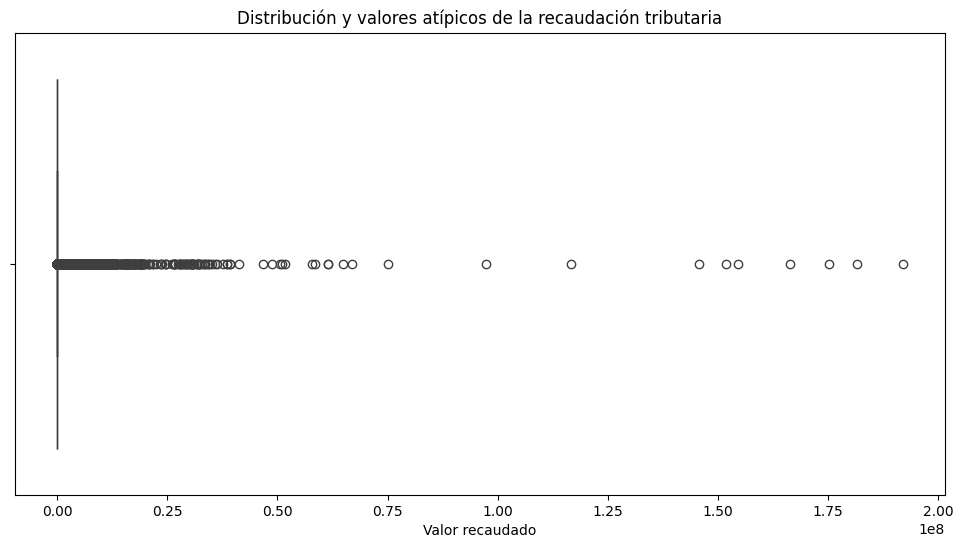

In [21]:
# ============================================
# 8.3. BOXPLOT DE VALOR_RECAUDADO
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(12, 6))

# Creamos el diagrama de caja.
sns.boxplot(x=df["VALOR_RECAUDADO"])

# Título del gráfico.
plt.title("Distribución y valores atípicos de la recaudación tributaria")

# Nombre del eje X.
plt.xlabel("Valor recaudado")

# Mostramos el gráfico.
plt.show()

## 9. Distribución de la recaudación tributaria

Debido a la presencia de valores elevados en la variable
`VALOR_RECAUDADO`, el diagrama de caja muestra una fuerte concentración
de observaciones cerca de valores bajos.

Por esta razón, se utilizará un histograma para observar con mayor
claridad la distribución de los valores de recaudación.

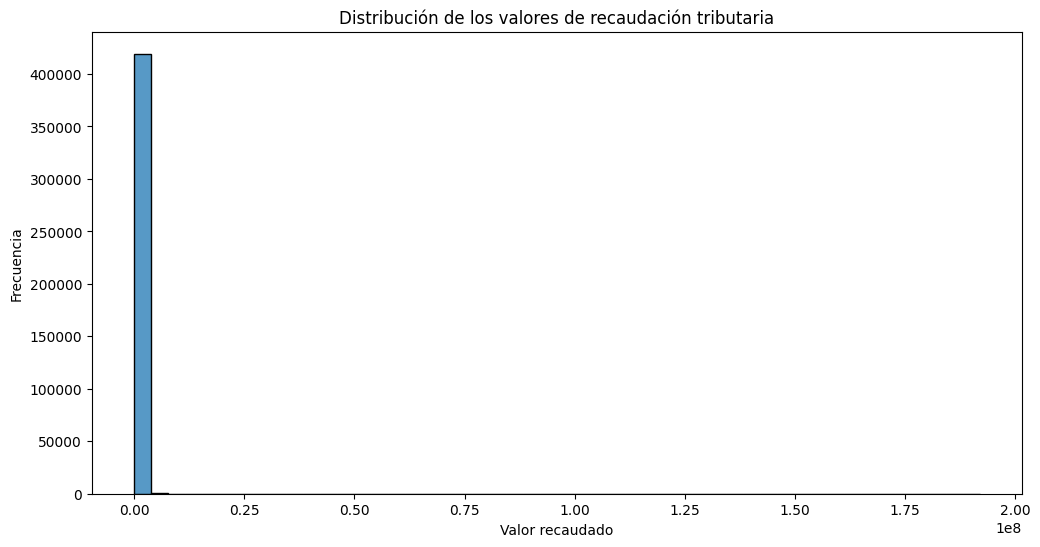

In [22]:
# ============================================
# 9.1. HISTOGRAMA DE VALOR_RECAUDADO
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(12, 6))

# Generamos el histograma de la recaudación.
sns.histplot(
    data=df,
    x="VALOR_RECAUDADO",
    bins=50
)

# Agregamos título y etiquetas.
plt.title("Distribución de los valores de recaudación tributaria")
plt.xlabel("Valor recaudado")
plt.ylabel("Frecuencia")

# Mostramos el gráfico.
plt.show()

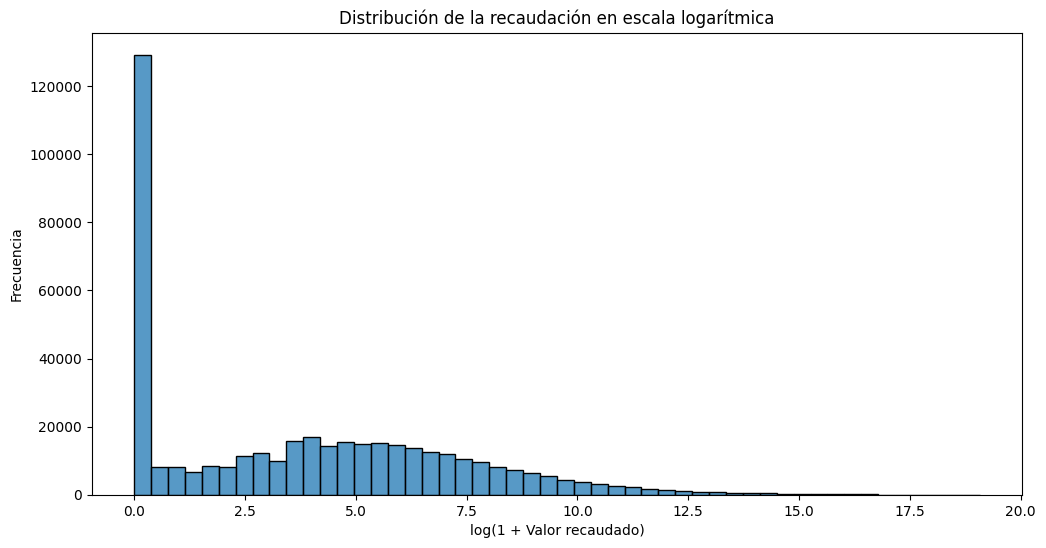

In [23]:
# ============================================
# 9.2. DISTRIBUCIÓN EN ESCALA LOGARÍTMICA
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(12, 6))

# Utilizamos log1p para poder representar también
# los valores que son iguales a cero.
sns.histplot(
    np.log1p(df["VALOR_RECAUDADO"]),
    bins=50
)

# Agregamos título y etiquetas.
plt.title("Distribución de la recaudación en escala logarítmica")
plt.xlabel("log(1 + Valor recaudado)")
plt.ylabel("Frecuencia")

# Mostramos el gráfico.
plt.show()

## 10. Análisis de la recaudación por mes

Se analizará el comportamiento de la recaudación tributaria durante el
período comprendido entre enero y julio de 2026.

Para ello se agruparán los registros por mes y se calculará el valor total
recaudado en cada período. Este análisis permitirá identificar diferencias
en los niveles de recaudación entre los meses analizados.

In [25]:
# ============================================
# 10.1. PREPARACIÓN DE LA VARIABLE MES
# ============================================

# Extraemos los dos primeros caracteres de la variable MES
# para obtener el número correspondiente al mes.
df["MES_NUM"] = df["MES"].str[:2].astype(int)

# Comprobamos los valores obtenidos.
print(df[["MES", "MES_NUM"]].drop_duplicates().sort_values("MES_NUM"))

              MES  MES_NUM
0        01 Enero        1
3800   02 Febrero        2
7200     03 Marzo        3
11441    04 Abril        4
15411     05 Mayo        5
19200    06 Junio        6
100      07 Julio        7


In [26]:
# ============================================
# 10.2. RECAUDACIÓN TOTAL POR MES
# ============================================

# Agrupamos los registros por número de mes
# y calculamos la suma de la recaudación.
recaudacion_mensual = (
    df.groupby("MES_NUM")["VALOR_RECAUDADO"]
      .sum()
      .reset_index()
)

# Mostramos los resultados.
recaudacion_mensual

,MES_NUM,VALOR_RECAUDADO
0,1,2.298775e+09
1,2,1.587961e+09
2,3,1.991705e+09
3,4,2.864091e+09
4,5,1.951633e+09
5,6,1.883585e+09
6,7,2.002718e+09


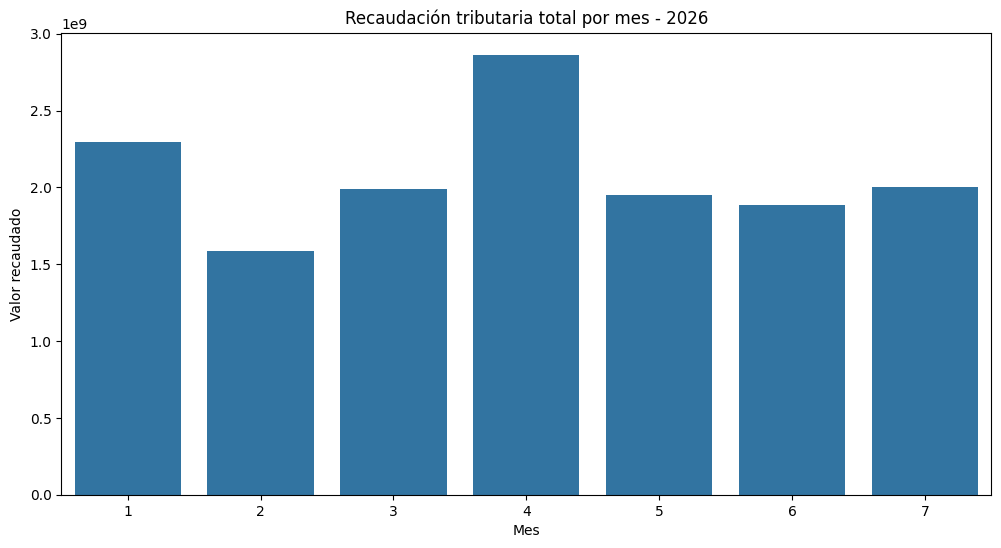

In [27]:
# ============================================
# 10.3. GRÁFICO DE RECAUDACIÓN MENSUAL
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(12, 6))

# Creamos un gráfico de barras con la recaudación
# total correspondiente a cada mes.
sns.barplot(
    data=recaudacion_mensual,
    x="MES_NUM",
    y="VALOR_RECAUDADO"
)

# Agregamos título y etiquetas.
plt.title("Recaudación tributaria total por mes - 2026")
plt.xlabel("Mes")
plt.ylabel("Valor recaudado")

# Mostramos el gráfico.
plt.show()

## 11. Análisis de la recaudación por provincia

Se analizará la distribución de la recaudación tributaria entre las
diferentes provincias registradas en el conjunto de datos.

Para ello se agruparán los registros por provincia y se calculará el
valor total recaudado. Posteriormente se identificarán las provincias
con mayores niveles de recaudación.

In [28]:
# ============================================
# 11.1. RECAUDACIÓN TOTAL POR PROVINCIA
# ============================================

# Agrupamos los registros por provincia y calculamos
# la suma total del valor recaudado.
recaudacion_provincia = (
    df.groupby("PROVINCIA")["VALOR_RECAUDADO"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Mostramos las primeras provincias con mayor recaudación.
recaudacion_provincia.head(10)

,PROVINCIA,VALOR_RECAUDADO
0,PICHINCHA,6.992182e+09
1,GUAYAS,4.428946e+09
2,ZAMORA CHINCHIPE,8.356421e+08
3,AZUAY,6.494895e+08
4,EL ORO,3.004594e+08
5,MANABI,2.917817e+08
6,TUNGURAHUA,2.434014e+08
7,COTOPAXI,1.303968e+08
8,SANTO DOMINGO DE LOS TSÁCHILAS,8.806056e+07
9,IMBABURA,8.496181e+07


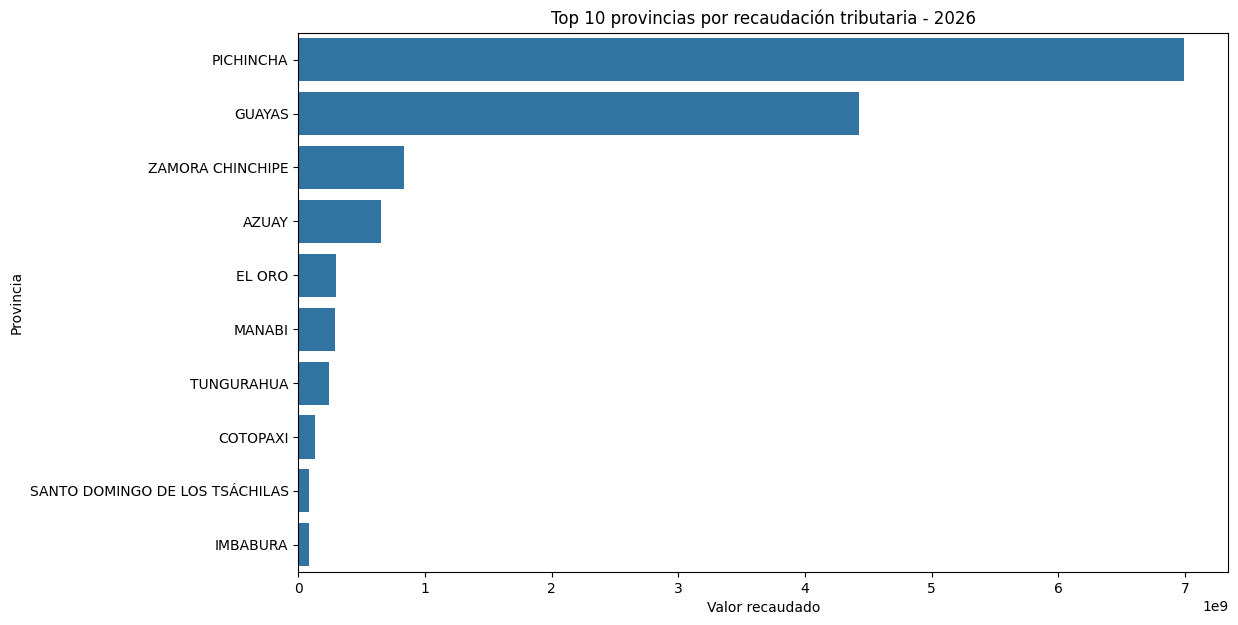

In [29]:
# ============================================
# 11.2. TOP 10 PROVINCIAS POR RECAUDACIÓN
# ============================================

# Seleccionamos las 10 provincias con mayor
# valor total recaudado.
top_10_provincias = recaudacion_provincia.head(10)

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(12, 7))

# Creamos el gráfico de barras.
sns.barplot(
    data=top_10_provincias,
    x="VALOR_RECAUDADO",
    y="PROVINCIA"
)

# Agregamos título y etiquetas.
plt.title("Top 10 provincias por recaudación tributaria - 2026")
plt.xlabel("Valor recaudado")
plt.ylabel("Provincia")

# Mostramos el gráfico.
plt.show()

## 12. Análisis de la recaudación por tipo de contribuyente

Se analizará la recaudación tributaria de acuerdo con el tipo de
contribuyente registrado en el conjunto de datos.

Para ello se agruparán los registros por la variable `TIPO_CONTRIBUYENTE`
y se calculará el valor total recaudado para cada categoría.

In [30]:
# ============================================
# 12.1. RECAUDACIÓN POR TIPO DE CONTRIBUYENTE
# ============================================

# Agrupamos los registros según el tipo de contribuyente
# y calculamos la suma total de la recaudación.
recaudacion_contribuyente = (
    df.groupby("TIPO_CONTRIBUYENTE")["VALOR_RECAUDADO"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Mostramos la tabla resultante.
recaudacion_contribuyente

,TIPO_CONTRIBUYENTE,VALOR_RECAUDADO
0,SOCIEDADES,1.356421e+10
1,PERSONAS NATURALES,7.863200e+08
2,NO TIENE,2.299381e+08


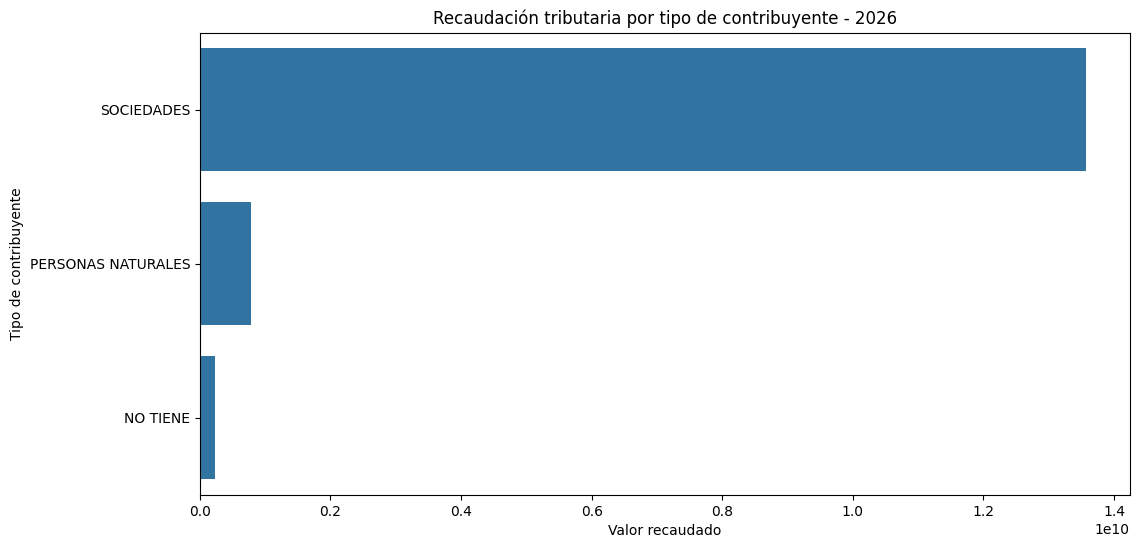

In [31]:
# ============================================
# 12.2. GRÁFICO POR TIPO DE CONTRIBUYENTE
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(12, 6))

# Creamos un gráfico de barras.
sns.barplot(
    data=recaudacion_contribuyente,
    x="VALOR_RECAUDADO",
    y="TIPO_CONTRIBUYENTE"
)

# Agregamos título y etiquetas.
plt.title("Recaudación tributaria por tipo de contribuyente - 2026")
plt.xlabel("Valor recaudado")
plt.ylabel("Tipo de contribuyente")

# Mostramos el gráfico.
plt.show()

## 13. Análisis de la recaudación por tipo de impuesto

Se analizará la distribución de la recaudación tributaria según el tipo
de impuesto registrado en el conjunto de datos.

Para facilitar la interpretación, se calculará el valor total recaudado
por cada impuesto y se seleccionarán los diez impuestos con mayor
recaudación acumulada durante el período analizado.

In [32]:
# ============================================
# 13.1. RECAUDACIÓN POR TIPO DE IMPUESTO
# ============================================

# Agrupamos los registros por tipo de impuesto
# y calculamos la suma total de la recaudación.
recaudacion_impuesto = (
    df.groupby("IMPUESTO")["VALOR_RECAUDADO"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Mostramos los 10 impuestos con mayor recaudación.
recaudacion_impuesto.head(10)

,IMPUESTO,VALOR_RECAUDADO
0,IVA MENSUAL,5.274481e+09
1,RETENCIONES EN LA FUENTE,2.389565e+09
2,IVA EXTERNO,1.840491e+09
3,AUTORRETENCION DE GRANDES CONTRIBUYENTES,1.363722e+09
4,IMPUESTO A LA SALIDA DE DIVISAS,8.180213e+08
5,RENTA SOCIEDADES,7.944450e+08
6,UTILIDADES DE LAS ACTIVIDADES MINERAS,2.576602e+08
7,RENTA PERSONAS NATURALES,2.459111e+08
8,ICE-CERVEZA INDUSTRIAL,2.013240e+08
9,CONTRIBUCION PARA LA ATENCION INTEGRAL DEL CANCER,1.565132e+08


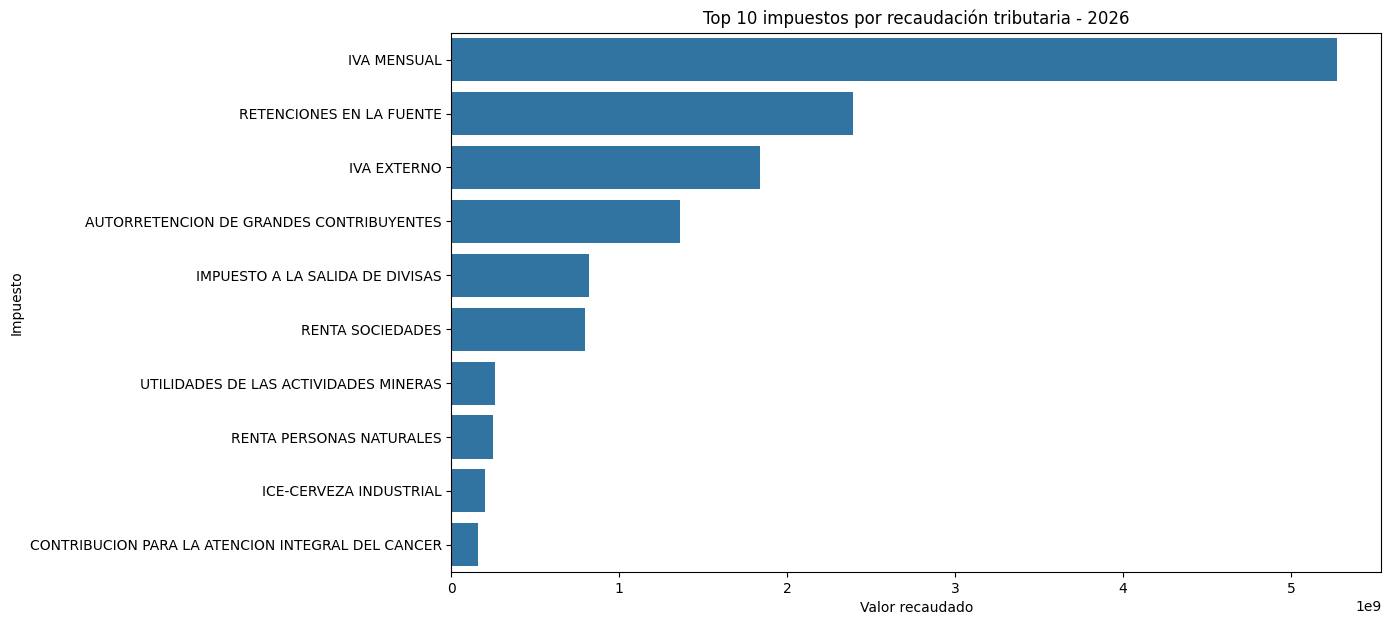

In [33]:
# ============================================
# 13.2. TOP 10 IMPUESTOS POR RECAUDACIÓN
# ============================================

# Seleccionamos los 10 impuestos con mayor
# valor acumulado de recaudación.
top_10_impuestos = recaudacion_impuesto.head(10)

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(12, 7))

# Creamos el gráfico de barras.
sns.barplot(
    data=top_10_impuestos,
    x="VALOR_RECAUDADO",
    y="IMPUESTO"
)

# Agregamos título y etiquetas.
plt.title("Top 10 impuestos por recaudación tributaria - 2026")
plt.xlabel("Valor recaudado")
plt.ylabel("Impuesto")

# Mostramos el gráfico.
plt.show()

## 14. Feature Engineering

El feature engineering consiste en crear nuevas variables a partir de
las variables existentes con el propósito de obtener información útil
para el análisis y el modelado.

En este proyecto se utilizarán dos variables derivadas:

1. `MES_NUM`: representa numéricamente el mes a partir de la variable `MES`.
2. `VALOR_LOG`: transformación logarítmica de `VALOR_RECAUDADO`, utilizada
   para reducir el efecto de la fuerte asimetría observada en la variable
   de recaudación.

In [34]:
# ============================================
# 14.1. CREACIÓN DE LA VARIABLE VALOR_LOG
# ============================================

# Creamos una transformación logarítmica de la variable
# VALOR_RECAUDADO.
#
# Se utiliza log1p() porque permite trabajar correctamente
# con registros cuyo valor de recaudación es igual a cero.
df["VALOR_LOG"] = np.log1p(df["VALOR_RECAUDADO"])

# Mostramos algunas columnas para comprobar la transformación.
df[["VALOR_RECAUDADO", "VALOR_LOG"]].head(10)

,VALOR_RECAUDADO,VALOR_LOG
0,7.964000e+01,4.389995
1,1.816221e+08,19.017438
2,3.575260e+03,8.182073
3,3.969730e+04,10.589064
4,8.798200e+02,6.780853
5,2.821900e+02,5.646118
6,1.809000e+02,5.203457
7,1.896086e+04,9.850185
8,1.683860e+03,7.429438
9,2.614524e+05,12.474011


In [35]:
# ============================================
# 14.2. VERIFICACIÓN DE VARIABLES DERIVADAS
# ============================================

# Mostramos las variables derivadas creadas durante
# el proceso de feature engineering.
print("Variables derivadas:")

print("1. MES_NUM")
print("2. VALOR_LOG")

# Mostramos las primeras filas.
df[["MES", "MES_NUM", "VALOR_RECAUDADO", "VALOR_LOG"]].head()

Variables derivadas:
1. MES_NUM
2. VALOR_LOG


,MES,MES_NUM,VALOR_RECAUDADO,VALOR_LOG
0,01 Enero,1,7.964000e+01,4.389995
1,01 Enero,1,1.816221e+08,19.017438
2,01 Enero,1,3.575260e+03,8.182073
3,01 Enero,1,3.969730e+04,10.589064
4,01 Enero,1,8.798200e+02,6.780853


## 15. Preparación de variables para el modelado

Para construir los modelos predictivos se identificarán las variables
independientes y la variable objetivo.

La variable objetivo será `VALOR_RECAUDADO`, debido a que el propósito
del modelado será estimar el valor de la recaudación a partir de las
características disponibles en el conjunto de datos.

Las variables categóricas serán posteriormente transformadas mediante
One-Hot Encoding para que puedan ser utilizadas por los algoritmos de
aprendizaje automático.

In [36]:
# ============================================
# 15.1. DEFINICIÓN DE VARIABLES
# ============================================

# Definimos la variable objetivo (y).
# Es el valor que queremos predecir.
y = df["VALOR_RECAUDADO"]

# Definimos las variables predictoras (X).
# Estas variables serán utilizadas por los modelos
# para realizar las predicciones.
X = df[
    [
        "ANIO",
        "MES_NUM",
        "GRUPO_IMPUESTO",
        "SUBGRUPO_IMPUESTO",
        "IMPUESTO",
        "GRAN_CONTRIBUYENTE",
        "CODIGO_OPERA_FAMILIA",
        "TIPO_CONTRIBUYENTE",
        "PROVINCIA",
        "CANTON"
    ]
]

# Comprobamos las dimensiones.
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (420031, 10)
Dimensiones de y: (420031,)


In [37]:
# ============================================
# 15.2. IDENTIFICACIÓN DE VARIABLES
# ============================================

# Variables numéricas.
variables_numericas = [
    "ANIO",
    "MES_NUM"
]

# Variables categóricas.
variables_categoricas = [
    "GRUPO_IMPUESTO",
    "SUBGRUPO_IMPUESTO",
    "IMPUESTO",
    "GRAN_CONTRIBUYENTE",
    "CODIGO_OPERA_FAMILIA",
    "TIPO_CONTRIBUYENTE",
    "PROVINCIA",
    "CANTON"
]

# Mostramos las variables identificadas.
print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['ANIO', 'MES_NUM']

Variables categóricas:
['GRUPO_IMPUESTO', 'SUBGRUPO_IMPUESTO', 'IMPUESTO', 'GRAN_CONTRIBUYENTE', 'CODIGO_OPERA_FAMILIA', 'TIPO_CONTRIBUYENTE', 'PROVINCIA', 'CANTON']


In [38]:
# ============================================
# 15.3. COMPROBACIÓN DE LAS VARIABLES
# ============================================

print("Número de variables numéricas:",
      len(variables_numericas))

print("Número de variables categóricas:",
      len(variables_categoricas))

print("Total de variables predictoras:",
      len(variables_numericas) + len(variables_categoricas))

Número de variables numéricas: 2
Número de variables categóricas: 8
Total de variables predictoras: 10


## 16. División del conjunto de datos

Para evaluar el rendimiento de los modelos predictivos se dividirá el
conjunto de datos en dos subconjuntos.

El 80 % de los registros será utilizado para el entrenamiento de los
modelos, mientras que el 20 % restante será utilizado para realizar las
pruebas.

Se utilizará `random_state=42` para garantizar que la división sea
reproducible y que los resultados puedan repetirse bajo las mismas
condiciones.

In [39]:
# ============================================
# 16.1. DIVISIÓN TRAIN / TEST
# ============================================

# Dividimos las variables predictoras (X) y la variable
# objetivo (y) en conjuntos de entrenamiento y prueba.
#
# test_size=0.20 significa que el 20 % de los datos
# será utilizado para realizar las pruebas.
#
# random_state=42 permite reproducir la misma división
# cada vez que ejecutemos el código.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Mostramos las dimensiones de cada conjunto.
print("Datos de entrenamiento:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nDatos de prueba:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Datos de entrenamiento:
X_train: (336024, 10)
y_train: (336024,)

Datos de prueba:
X_test: (84007, 10)
y_test: (84007,)


## 17. Preprocesamiento de variables categóricas

El conjunto de datos contiene variables categóricas relacionadas con
impuestos, contribuyentes y ubicación geográfica.

Debido a que los algoritmos de aprendizaje automático requieren
representaciones numéricas, las variables categóricas serán transformadas
mediante la técnica One-Hot Encoding.

Las variables numéricas se mantendrán sin esta transformación.

In [41]:
# ============================================
# 17.1. PREPROCESAMIENTO
# ============================================

# Creamos un transformador que aplicará:
#
# - OneHotEncoder a las variables categóricas.
# - passthrough a las variables numéricas.
#
# handle_unknown="ignore" evita errores si durante
# las pruebas aparece una categoría que no apareció
# durante el entrenamiento.

preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            variables_categoricas
        ),
        (
            "numericas",
            "passthrough",
            variables_numericas
        )
    ]
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


## 18. Modelo 1: Regresión Lineal

La regresión lineal será utilizada como modelo de referencia para
predecir el valor de la recaudación tributaria.

El modelo recibirá las variables numéricas y categóricas previamente
transformadas y generará una predicción de `VALOR_RECAUDADO`.

Su rendimiento será posteriormente evaluado mediante MAE, RMSE y R².

In [43]:
# ============================================
# 18.1. MODELO DE REGRESIÓN LINEAL
# ============================================

# Creamos un Pipeline que integra:
#
# 1. Preprocesamiento de los datos.
# 2. Entrenamiento del modelo de regresión lineal.

modelo_regresion = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        ("modelo", LinearRegression())
    ]
)

print("Pipeline de Regresión Lineal creado correctamente.")

Pipeline de Regresión Lineal creado correctamente.


In [44]:
# ============================================
# 18.2. ENTRENAMIENTO DEL MODELO
# ============================================

# Entrenamos el modelo utilizando únicamente
# los datos de entrenamiento.
modelo_regresion.fit(
    X_train,
    y_train
)

print("Modelo de Regresión Lineal entrenado correctamente.")

Modelo de Regresión Lineal entrenado correctamente.


In [45]:
# ============================================
# 18.3. PREDICCIONES
# ============================================

# Utilizamos el conjunto de prueba para generar
# las predicciones del modelo.
y_pred_regresion = modelo_regresion.predict(X_test)

# Mostramos las primeras cinco predicciones.
print("Primeras cinco predicciones:")

print(y_pred_regresion[:5])

Primeras cinco predicciones:
[-59345.11700557 -48279.3978735  -41844.79957418 -55373.94573357
 -49700.20082272]


## 19. Evaluación del modelo de Regresión Lineal

Una vez entrenado el modelo de Regresión Lineal, se evaluará su capacidad
predictiva utilizando tres métricas: MAE, RMSE y R².

El MAE permitirá medir el error absoluto promedio de las predicciones.
El RMSE permitirá dar mayor peso a los errores de mayor magnitud.
El R² permitirá evaluar la proporción de variabilidad de la variable
objetivo explicada por el modelo.

In [46]:
# ============================================
# 19.1. EVALUACIÓN DE LA REGRESIÓN LINEAL
# ============================================

# Calculamos el Error Absoluto Medio (MAE).
mae_regresion = mean_absolute_error(
    y_test,
    y_pred_regresion
)

# Calculamos el Error Cuadrático Medio (MSE).
mse_regresion = mean_squared_error(
    y_test,
    y_pred_regresion
)

# Calculamos el Error Cuadrático Medio de la Raíz (RMSE).
rmse_regresion = np.sqrt(mse_regresion)

# Calculamos el coeficiente de determinación R².
r2_regresion = r2_score(
    y_test,
    y_pred_regresion
)

# Mostramos las métricas obtenidas.
print("=== EVALUACIÓN DE REGRESIÓN LINEAL ===")
print(f"MAE :  {mae_regresion:,.2f}")
print(f"RMSE:  {rmse_regresion:,.2f}")
print(f"R²  :  {r2_regresion:.4f}")

=== EVALUACIÓN DE REGRESIÓN LINEAL ===
MAE :  98,995.44
RMSE:  919,507.04
R²  :  0.0454


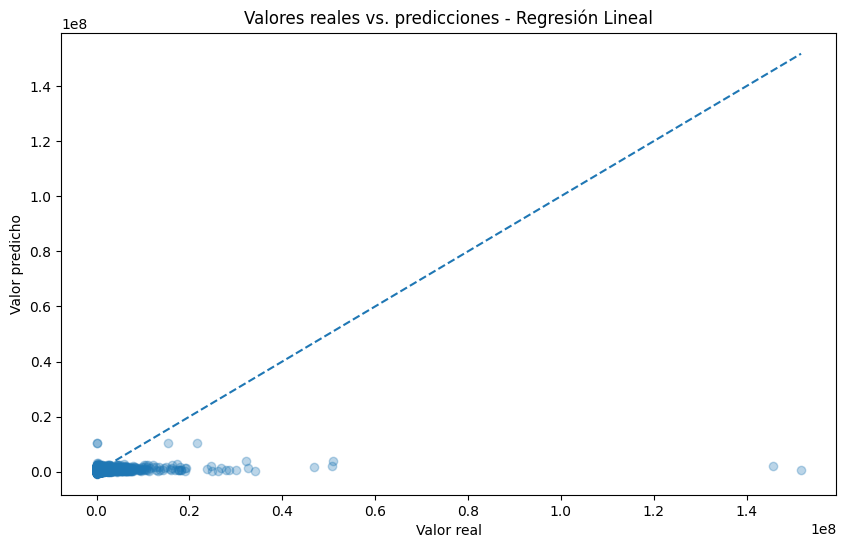

In [47]:
# ============================================
# 20.1. VALORES REALES VS. PREDICCIONES
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(10, 6))

# Graficamos los valores reales y las predicciones.
plt.scatter(
    y_test,
    y_pred_regresion,
    alpha=0.3
)

# Línea de referencia:
# si una predicción fuera perfecta, estaría sobre esta línea.
limite_maximo = max(
    y_test.max(),
    y_pred_regresion.max()
)

plt.plot(
    [0, limite_maximo],
    [0, limite_maximo],
    linestyle="--"
)

# Título y etiquetas.
plt.title("Valores reales vs. predicciones - Regresión Lineal")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")

# Mostramos el gráfico.
plt.show()

## 21. Modelo 2: Random Forest Regressor

Random Forest Regressor es un algoritmo de aprendizaje automático basado
en múltiples árboles de decisión.

A diferencia de la regresión lineal, este modelo puede representar
relaciones no lineales entre las variables predictoras y la variable
objetivo.

Se utilizará como segundo modelo predictivo para comparar su rendimiento
con la Regresión Lineal.

In [48]:
# ============================================
# 21.1. MODELO RANDOM FOREST
# ============================================

# Creamos el modelo Random Forest para regresión.
#
# n_estimators=50:
# Utilizaremos 50 árboles de decisión.
#
# max_depth=12:
# Limitamos la profundidad de los árboles para
# controlar la complejidad del modelo.
#
# random_state=42:
# Permite reproducir los resultados.
#
# n_jobs=-1:
# Utiliza los núcleos disponibles del entorno
# para acelerar el entrenamiento.

modelo_random_forest = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            RandomForestRegressor(
                n_estimators=50,
                max_depth=12,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Pipeline de Random Forest creado correctamente.")

Pipeline de Random Forest creado correctamente.


In [49]:
# ============================================
# 21.2. ENTRENAMIENTO DE RANDOM FOREST
# ============================================

# Entrenamos el modelo utilizando los datos
# de entrenamiento.
modelo_random_forest.fit(
    X_train,
    y_train
)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


In [50]:
# ============================================
# 21.3. PREDICCIONES DE RANDOM FOREST
# ============================================

# Generamos las predicciones utilizando
# el conjunto de prueba.
y_pred_rf = modelo_random_forest.predict(X_test)

# Mostramos las primeras cinco predicciones.
print("Primeras cinco predicciones de Random Forest:")
print(y_pred_rf[:5])

Primeras cinco predicciones de Random Forest:
[ 862.79626798  842.21964008 5966.16019802  862.79626798  842.21964008]


## 22. Evaluación del modelo Random Forest

Se evaluará el modelo Random Forest utilizando las mismas métricas
empleadas para la Regresión Lineal: MAE, RMSE y R².

La utilización de las mismas métricas permite realizar posteriormente
una comparación objetiva entre los modelos implementados.

In [51]:
# ============================================
# 22.1. EVALUACIÓN DE RANDOM FOREST
# ============================================

# Calculamos el Error Absoluto Medio (MAE).
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

# Calculamos el Error Cuadrático Medio (MSE).
mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

# Calculamos el RMSE.
rmse_rf = np.sqrt(mse_rf)

# Calculamos el coeficiente de determinación R².
r2_rf = r2_score(
    y_test,
    y_pred_rf
)

# Mostramos las métricas.
print("=== EVALUACIÓN DE RANDOM FOREST ===")
print(f"MAE :  {mae_rf:,.2f}")
print(f"RMSE:  {rmse_rf:,.2f}")
print(f"R²  :  {r2_rf:.4f}")

=== EVALUACIÓN DE RANDOM FOREST ===
MAE :  24,668.41
RMSE:  549,657.39
R²  :  0.6589


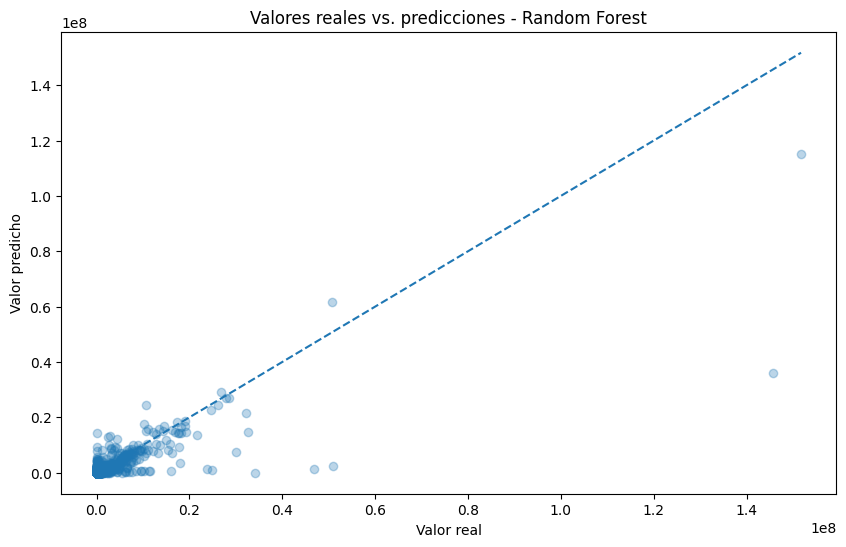

In [52]:
# ============================================
# 23.1. VALORES REALES VS. PREDICCIONES
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(10, 6))

# Graficamos los valores reales frente
# a las predicciones de Random Forest.
plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

# Calculamos el límite máximo para la línea de referencia.
limite_maximo_rf = max(
    y_test.max(),
    y_pred_rf.max()
)

# Línea diagonal que representa una predicción perfecta.
plt.plot(
    [0, limite_maximo_rf],
    [0, limite_maximo_rf],
    linestyle="--"
)

# Título y etiquetas.
plt.title("Valores reales vs. predicciones - Random Forest")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")

# Mostramos el gráfico.
plt.show()

## 24. Modelo 3: HistGradientBoosting Regressor

HistGradientBoosting Regressor es un algoritmo de aprendizaje automático
basado en Gradient Boosting.

El modelo construye una secuencia de árboles de decisión, donde cada etapa
busca mejorar los errores producidos por las etapas anteriores.

Se utilizará como tercer modelo predictivo y sus resultados serán
evaluados mediante MAE, RMSE y R², utilizando el mismo conjunto de prueba
empleado para los modelos anteriores.

In [53]:
# ============================================
# 24.1. MODELO HISTGRADIENTBOOSTING
# ============================================

# Creamos el modelo basado en Gradient Boosting.
#
# max_iter=100:
# Número máximo de iteraciones o árboles.
#
# learning_rate=0.10:
# Controla cuánto contribuye cada árbol al modelo final.
#
# max_leaf_nodes=31:
# Limita el número máximo de hojas de cada árbol.
#
# random_state=42:
# Permite reproducir los resultados.

modelo_gradient = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "modelo",
            HistGradientBoostingRegressor(
                max_iter=100,
                learning_rate=0.10,
                max_leaf_nodes=31,
                random_state=42
            )
        )
    ]
)

print("Pipeline de HistGradientBoosting creado correctamente.")

Pipeline de HistGradientBoosting creado correctamente.


## 24. Corrección del preprocesamiento para HistGradientBoosting

Durante el entrenamiento del modelo HistGradientBoosting se produjo un
error debido a que el preprocesamiento mediante One-Hot Encoding genera
una matriz dispersa (sparse), mientras que HistGradientBoosting requiere
una representación densa para esta configuración.

Para solucionar este inconveniente se utilizará `OrdinalEncoder` para
representar las variables categóricas mediante códigos numéricos.

Además, las variables categóricas serán indicadas explícitamente al
modelo para que HistGradientBoosting pueda tratarlas como variables
categóricas.

In [56]:
# ============================================
# 24.1. IMPORTACIÓN DE ORDINAL ENCODER
# ============================================

# OrdinalEncoder transforma las variables categóricas
# en códigos numéricos.
#
# A diferencia de OneHotEncoder, no genera cientos o miles
# de columnas adicionales, por lo que resulta más eficiente
# para trabajar con un dataset de gran tamaño.

from sklearn.preprocessing import OrdinalEncoder

print("OrdinalEncoder importado correctamente.")

OrdinalEncoder importado correctamente.


In [57]:
# ============================================
# 24.2. PREPROCESADOR PARA HISTGRADIENTBOOSTING
# ============================================

# Creamos un preprocesador específico para el tercer modelo.
#
# Las variables categóricas serán transformadas mediante
# OrdinalEncoder.
#
# handle_unknown="use_encoded_value":
# Permite manejar categorías que no aparezcan durante
# el entrenamiento.
#
# unknown_value=-1:
# Asigna el valor -1 a las categorías desconocidas.
#
# Las variables numéricas se mantienen sin transformación.

preprocesador_gradient = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            variables_categoricas
        ),
        (
            "numericas",
            "passthrough",
            variables_numericas
        )
    ]
)

print("Preprocesador para HistGradientBoosting creado correctamente.")

Preprocesador para HistGradientBoosting creado correctamente.


In [58]:
# ============================================
# 24.3. MODELO HISTGRADIENTBOOSTING CORREGIDO
# ============================================

# Creamos el modelo HistGradientBoosting.
#
# max_iter=100:
# Número máximo de iteraciones.
#
# learning_rate=0.10:
# Tasa de aprendizaje del modelo.
#
# max_leaf_nodes=31:
# Número máximo de hojas por árbol.
#
# random_state=42:
# Permite reproducir los resultados.

modelo_gradient = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_gradient
        ),
        (
            "modelo",
            HistGradientBoostingRegressor(
                max_iter=100,
                learning_rate=0.10,
                max_leaf_nodes=31,
                random_state=42,
                categorical_features=[
                    True, True, True, True,
                    True, True, True, True,
                    False, False
                ]
            )
        )
    ]
)

print("Pipeline de HistGradientBoosting creado correctamente.")

Pipeline de HistGradientBoosting creado correctamente.


In [60]:
# ============================================
# 24.4. ENTRENAMIENTO
# ============================================

# Entrenamos HistGradientBoosting utilizando
# únicamente los datos de entrenamiento.

modelo_gradient.fit(
    X_train,
    y_train
)

print("Modelo HistGradientBoosting entrenado correctamente.")

Modelo HistGradientBoosting entrenado correctamente.


In [61]:
# ============================================
# 24.5. PREDICCIONES
# ============================================

# Generamos las predicciones sobre el conjunto de prueba.
y_pred_gradient = modelo_gradient.predict(X_test)

# Mostramos las primeras cinco predicciones.
print("Primeras cinco predicciones de HistGradientBoosting:")
print(y_pred_gradient[:5])

Primeras cinco predicciones de HistGradientBoosting:
[-102.02890303 -218.50636177  571.56316018 -102.02890303 1495.69244656]


## 25. Evaluación del modelo HistGradientBoosting

El modelo HistGradientBoosting será evaluado utilizando las mismas
métricas aplicadas a los modelos anteriores: MAE, RMSE y R².

El uso de las mismas métricas permitirá comparar de forma homogénea
los tres modelos implementados.

In [62]:
# ============================================
# 25.1. EVALUACIÓN DE HISTGRADIENTBOOSTING
# ============================================

# Calculamos el Error Absoluto Medio (MAE).
mae_gradient = mean_absolute_error(
    y_test,
    y_pred_gradient
)

# Calculamos el Error Cuadrático Medio (MSE).
mse_gradient = mean_squared_error(
    y_test,
    y_pred_gradient
)

# Calculamos el RMSE.
rmse_gradient = np.sqrt(mse_gradient)

# Calculamos el coeficiente de determinación R².
r2_gradient = r2_score(
    y_test,
    y_pred_gradient
)

# Mostramos las métricas obtenidas.
print("=== EVALUACIÓN DE HISTGRADIENTBOOSTING ===")
print(f"MAE :  {mae_gradient:,.2f}")
print(f"RMSE:  {rmse_gradient:,.2f}")
print(f"R²  :  {r2_gradient:.4f}")

=== EVALUACIÓN DE HISTGRADIENTBOOSTING ===
MAE :  31,211.67
RMSE:  641,292.67
R²  :  0.5357


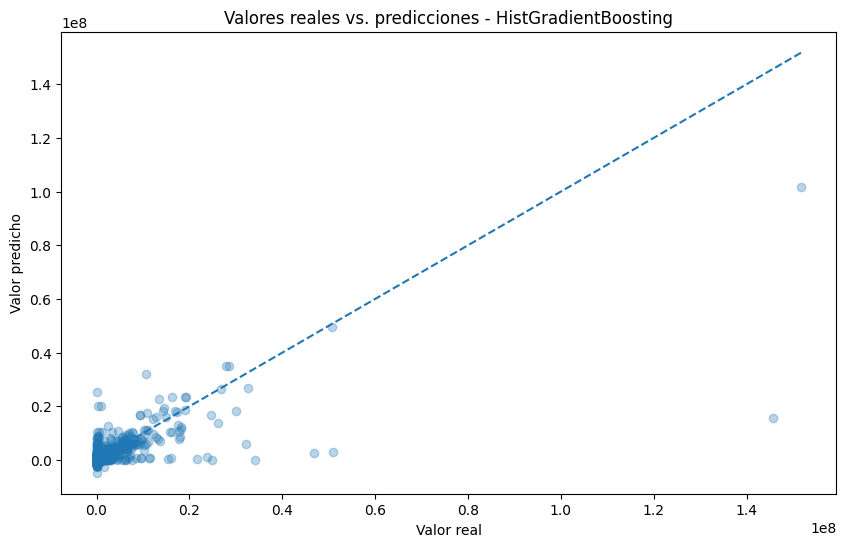

In [63]:
# ============================================
# 26.1. VALORES REALES VS. PREDICCIONES
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(10, 6))

# Graficamos los valores reales frente a las
# predicciones de HistGradientBoosting.
plt.scatter(
    y_test,
    y_pred_gradient,
    alpha=0.3
)

# Calculamos el límite máximo para la línea de referencia.
limite_maximo_gradient = max(
    y_test.max(),
    y_pred_gradient.max()
)

# Línea diagonal que representa una predicción perfecta.
plt.plot(
    [0, limite_maximo_gradient],
    [0, limite_maximo_gradient],
    linestyle="--"
)

# Título y etiquetas.
plt.title(
    "Valores reales vs. predicciones - HistGradientBoosting"
)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")

# Mostramos el gráfico.
plt.show()

## 27. Comparación de los modelos predictivos

Se compararán los resultados obtenidos por los tres modelos implementados:
Regresión Lineal, Random Forest e HistGradientBoosting.

La comparación se realizará utilizando las métricas MAE, RMSE y R²,
calculadas sobre el mismo conjunto de datos de prueba.

In [64]:
# ============================================
# 27.1. TABLA COMPARATIVA DE MODELOS
# ============================================

# Creamos una tabla con las métricas obtenidas
# por cada uno de los tres modelos.

resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "HistGradientBoosting"
    ],

    "MAE": [
        mae_regresion,
        mae_rf,
        mae_gradient
    ],

    "RMSE": [
        rmse_regresion,
        rmse_rf,
        rmse_gradient
    ],

    "R2": [
        r2_regresion,
        r2_rf,
        r2_gradient
    ]
})

# Mostramos la tabla.
resultados_modelos

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,98995.438384,919507.039527,0.045410
1,Random Forest,24668.414070,549657.386382,0.658893
2,HistGradientBoosting,31211.672167,641292.668624,0.535678


In [65]:
# ============================================
# 27.2. COMPARACIÓN ORDENADA POR R²
# ============================================

# Ordenamos los modelos según el valor de R²
# de mayor a menor únicamente para facilitar
# la visualización de los resultados.

resultados_ordenados = resultados_modelos.sort_values(
    by="R2",
    ascending=False
)

resultados_ordenados

,Modelo,MAE,RMSE,R2
1,Random Forest,24668.414070,549657.386382,0.658893
2,HistGradientBoosting,31211.672167,641292.668624,0.535678
0,Regresión Lineal,98995.438384,919507.039527,0.045410


## 28. Validación cruzada

Para evaluar la estabilidad de los modelos se aplicará validación cruzada
de 5 particiones (5-Fold Cross-Validation).

El conjunto de datos será dividido en cinco partes. En cada iteración,
cuatro partes serán utilizadas para entrenar el modelo y una parte para
evaluarlo.

El proceso se repetirá cinco veces, de manera que cada partición sea
utilizada una vez como conjunto de validación.

In [66]:
# ============================================
# 28.1. CONFIGURACIÓN DE VALIDACIÓN CRUZADA
# ============================================

# Creamos una validación cruzada de 5 particiones.
#
# shuffle=True:
# Mezcla los registros antes de realizar las particiones.
#
# random_state=42:
# Permite reproducir la misma división.

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Validación cruzada configurada con 5 particiones.")

Validación cruzada configurada con 5 particiones.


In [67]:
# ============================================
# 29.1. VALIDACIÓN CRUZADA - RANDOM FOREST
# ============================================

# Evaluamos Random Forest mediante validación cruzada.
#
# neg_root_mean_squared_error devuelve el RMSE
# con signo negativo porque Scikit-learn trabaja
# internamente bajo el criterio de maximizar scores.
#
# Posteriormente cambiamos el signo para obtener
# el RMSE positivo.

scores_rf = cross_val_score(
    modelo_random_forest,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Convertimos los resultados a valores positivos.
rmse_folds_rf = -scores_rf

print("RMSE de cada partición:")
print(rmse_folds_rf)

print("\nRMSE promedio:")
print(rmse_folds_rf.mean())

print("\nDesviación estándar:")
print(rmse_folds_rf.std())

RMSE de cada partición:
[560733.2551966  307246.88755279 296474.96748691 774362.24956466
 371750.89144896]

RMSE promedio:
462113.65024998534

Desviación estándar:
182652.85645055008


## 30. Validación cruzada de HistGradientBoosting

Se aplicará una validación cruzada de 5 particiones al modelo
HistGradientBoosting para analizar la estabilidad de su rendimiento
predictivo.

Se utilizará RMSE como métrica de evaluación y se calculará tanto el
resultado de cada partición como el promedio y la desviación estándar.

In [68]:
# ============================================
# 30.1. VALIDACIÓN CRUZADA
# HISTGRADIENTBOOSTING
# ============================================

# Evaluamos HistGradientBoosting mediante
# validación cruzada de 5 particiones.

scores_gradient = cross_val_score(
    modelo_gradient,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Convertimos los valores negativos de Scikit-learn
# a valores positivos de RMSE.
rmse_folds_gradient = -scores_gradient

# Mostramos el RMSE obtenido en cada partición.
print("RMSE de cada partición:")
print(rmse_folds_gradient)

# Calculamos el promedio de los cinco resultados.
print("\nRMSE promedio:")
print(rmse_folds_gradient.mean())

# Calculamos la desviación estándar.
print("\nDesviación estándar:")
print(rmse_folds_gradient.std())

RMSE de cada partición:
[632131.70553256 621487.65114492 414729.08904124 591517.80760844
 541207.80224155]

RMSE promedio:
560214.8111137437

Desviación estándar:
79288.88942481967


## 31. Validación cruzada de Regresión Lineal

Finalmente, se aplicará validación cruzada de 5 particiones al modelo de
Regresión Lineal.

Se utilizará RMSE como métrica para mantener el mismo criterio de
evaluación utilizado en Random Forest e HistGradientBoosting.

In [69]:
# ============================================
# 31.1. VALIDACIÓN CRUZADA
# REGRESIÓN LINEAL
# ============================================

# Evaluamos la Regresión Lineal mediante
# validación cruzada de 5 particiones.

scores_regresion = cross_val_score(
    modelo_regresion,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Convertimos los valores negativos a RMSE positivos.
rmse_folds_regresion = -scores_regresion

# Mostramos el RMSE de cada partición.
print("RMSE de cada partición:")
print(rmse_folds_regresion)

# Calculamos el RMSE promedio.
print("\nRMSE promedio:")
print(rmse_folds_regresion.mean())

# Calculamos la desviación estándar.
print("\nDesviación estándar:")
print(rmse_folds_regresion.std())

RMSE de cada partición:
[ 919509.01435521 1128355.67085806  779957.53203093  856501.47619112
  956978.49868308]

RMSE promedio:
928260.4384236808

Desviación estándar:
116689.77432190541


## 32. Resultados de la validación cruzada

Se consolidan los resultados obtenidos mediante validación cruzada de
5 particiones para los tres modelos implementados.

Se presentan el RMSE promedio y la desviación estándar, permitiendo
analizar tanto el nivel medio del error como su variabilidad entre
las diferentes particiones.

In [70]:
# ============================================
# 32.1. TABLA FINAL DE VALIDACIÓN CRUZADA
# ============================================

# Creamos una tabla con los resultados de
# validación cruzada de los tres modelos.

validacion_cruzada = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "HistGradientBoosting"
    ],

    "RMSE Promedio": [
        rmse_folds_regresion.mean(),
        rmse_folds_rf.mean(),
        rmse_folds_gradient.mean()
    ],

    "Desviación Estándar": [
        rmse_folds_regresion.std(),
        rmse_folds_rf.std(),
        rmse_folds_gradient.std()
    ]
})

# Mostramos la tabla.
validacion_cruzada

,Modelo,RMSE Promedio,Desviación Estándar
0,Regresión Lineal,928260.438424,116689.774322
1,Random Forest,462113.650250,182652.856451
2,HistGradientBoosting,560214.811114,79288.889425


## 33. Comparación final de los modelos

Se integran los resultados obtenidos en la evaluación sobre el conjunto
de prueba y la validación cruzada de 5 particiones.

Esta comparación permite analizar el comportamiento predictivo de los
tres modelos utilizando métricas de error y de capacidad explicativa.

In [71]:
# ============================================
# 33.1. TABLA FINAL DE MODELOS
# ============================================

# Creamos una tabla consolidada con todos
# los resultados obtenidos.

tabla_final = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "HistGradientBoosting"
    ],

    "MAE": [
        mae_regresion,
        mae_rf,
        mae_gradient
    ],

    "RMSE": [
        rmse_regresion,
        rmse_rf,
        rmse_gradient
    ],

    "R2": [
        r2_regresion,
        r2_rf,
        r2_gradient
    ],

    "RMSE_CV_Promedio": [
        rmse_folds_regresion.mean(),
        rmse_folds_rf.mean(),
        rmse_folds_gradient.mean()
    ],

    "Desviacion_CV": [
        rmse_folds_regresion.std(),
        rmse_folds_rf.std(),
        rmse_folds_gradient.std()
    ]
})

# Mostramos la tabla completa.
tabla_final

,Modelo,MAE,RMSE,R2,RMSE_CV_Promedio,Desviacion_CV
0,Regresión Lineal,98995.438384,919507.039527,0.045410,928260.438424,116689.774322
1,Random Forest,24668.414070,549657.386382,0.658893,462113.650250,182652.856451
2,HistGradientBoosting,31211.672167,641292.668624,0.535678,560214.811114,79288.889425


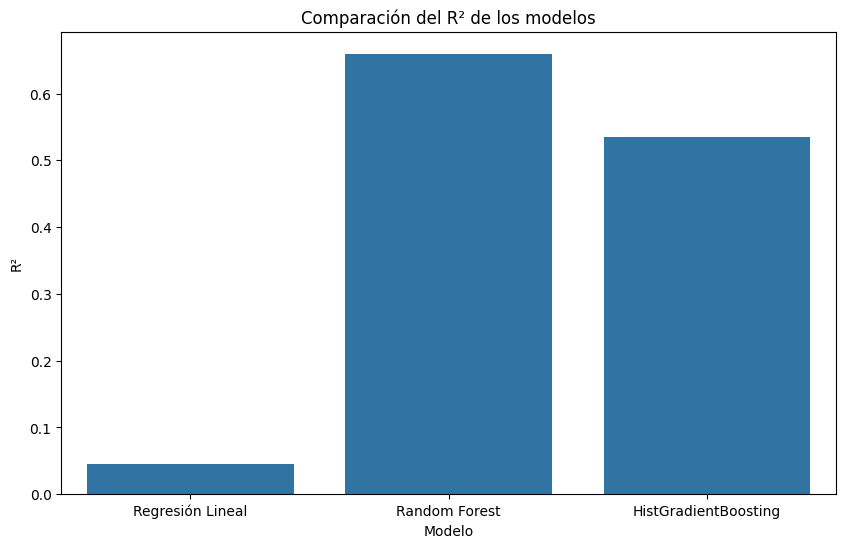

In [72]:
# ============================================
# 34.1. COMPARACIÓN DEL R²
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(10, 6))

# Creamos el gráfico de barras.
sns.barplot(
    data=tabla_final,
    x="Modelo",
    y="R2"
)

# Agregamos título y etiquetas.
plt.title("Comparación del R² de los modelos")
plt.xlabel("Modelo")
plt.ylabel("R²")

# Mostramos el gráfico.
plt.show()

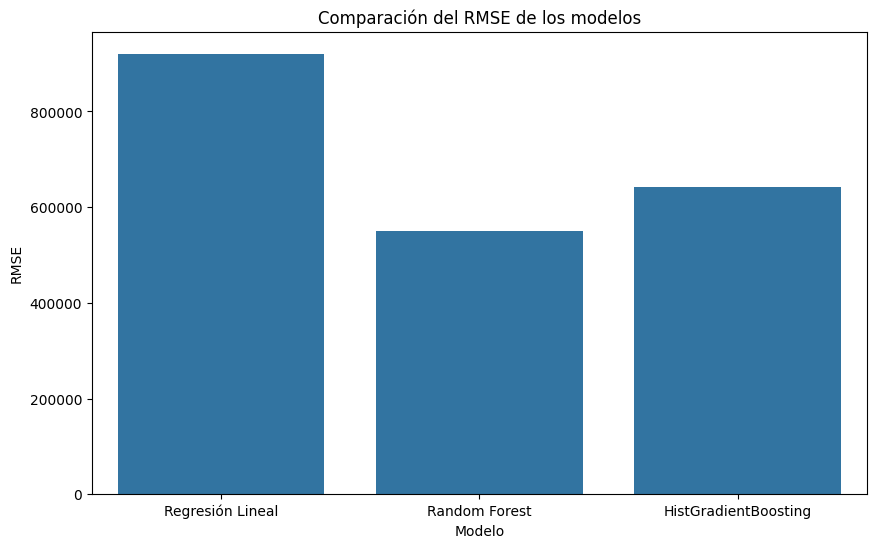

In [73]:
# ============================================
# 35.1. COMPARACIÓN DEL RMSE
# ============================================

# Configuramos el tamaño del gráfico.
plt.figure(figsize=(10, 6))

# Creamos el gráfico de barras.
sns.barplot(
    data=tabla_final,
    x="Modelo",
    y="RMSE"
)

# Agregamos título y etiquetas.
plt.title("Comparación del RMSE de los modelos")
plt.xlabel("Modelo")
plt.ylabel("RMSE")

# Mostramos el gráfico.
plt.show()

## 36. Conclusión del modelado predictivo

Se implementaron tres modelos de regresión para estimar la variable
`VALOR_RECAUDADO`: Regresión Lineal, Random Forest Regressor y
HistGradientBoosting Regressor.

La evaluación sobre el conjunto de prueba se realizó mediante las métricas
MAE, RMSE y R². Adicionalmente, se aplicó validación cruzada de 5
particiones utilizando RMSE como métrica de evaluación.

Los resultados evidenciaron diferencias entre los modelos. La Regresión
Lineal presentó un R² de 0,0454, mientras que Random Forest alcanzó 0,6589
y HistGradientBoosting obtuvo 0,5357 en el conjunto de prueba.

La validación cruzada permitió complementar estos resultados mediante el
análisis del RMSE promedio y su desviación estándar en cinco particiones.

Los resultados deben interpretarse considerando la fuerte asimetría de
`VALOR_RECAUDADO` y la presencia de valores de gran magnitud identificada
durante el análisis exploratorio.

In [74]:
# ============================================
# 37.1. TABLA FINAL PARA EL INFORME
# ============================================

# Creamos una copia de la tabla final.
tabla_informe = tabla_final.copy()

# Redondeamos los resultados para facilitar
# su presentación en el informe.
tabla_informe["MAE"] = tabla_informe["MAE"].round(2)
tabla_informe["RMSE"] = tabla_informe["RMSE"].round(2)
tabla_informe["R2"] = tabla_informe["R2"].round(4)
tabla_informe["RMSE_CV_Promedio"] = (
    tabla_informe["RMSE_CV_Promedio"].round(2)
)
tabla_informe["Desviacion_CV"] = (
    tabla_informe["Desviacion_CV"].round(2)
)

# Mostramos la tabla.
tabla_informe

,Modelo,MAE,RMSE,R2,RMSE_CV_Promedio,Desviacion_CV
0,Regresión Lineal,98995.44,919507.04,0.0454,928260.44,116689.77
1,Random Forest,24668.41,549657.39,0.6589,462113.65,182652.86
2,HistGradientBoosting,31211.67,641292.67,0.5357,560214.81,79288.89


In [75]:
# ============================================
# 40. GUARDAR LOS MODELOS ENTRENADOS
# ============================================

import joblib

# Guardamos el modelo de Regresión Lineal.
joblib.dump(
    modelo_regresion,
    "modelo_regresion_lineal.joblib"
)

# Guardamos el modelo Random Forest.
joblib.dump(
    modelo_random_forest,
    "modelo_random_forest.joblib"
)

# Guardamos el modelo HistGradientBoosting.
joblib.dump(
    modelo_gradient,
    "modelo_histgradientboosting.joblib"
)

print("Los tres modelos fueron guardados correctamente.")

Los tres modelos fueron guardados correctamente.


In [76]:
# ============================================
# 41. DESCARGAR LOS MODELOS
# ============================================

from google.colab import files

# Descargar Regresión Lineal
files.download("modelo_regresion_lineal.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
# ============================================
# 42. GUARDAR MODELO PARA LA API
# ============================================

import joblib

joblib.dump(
    modelo_random_forest,
    "modelo_random_forest.joblib"
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [79]:
from google.colab import files

files.download("modelo_random_forest.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>